<a href="https://colab.research.google.com/github/magmatic654/Challenge-Telecom-X-an-lisis-de-evasi-n-de-clientes/blob/main/TelecomX_LATAM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#📌 Extracción

In [ ]:
import pandas as pd
path = 'https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/refs/heads/main/TelecomX_Data.json'

df = pd.read_json(path)
df.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


#🔧 Transformación

## Conociendo el conjunto de datos

Diccionario de datos


- `customerID`: número de identificación único de cada cliente

- `Churn`: si el cliente dejó o no la empresa

- `gender`: género (masculino y femenino)

- `SeniorCitizen`: información sobre si un cliente tiene o no una edad igual o mayor a 65 años

- `Partner`: si el cliente tiene o no una pareja

- `Dependents`: si el cliente tiene o no dependientes

- `tenure`: meses de contrato del cliente

- `PhoneService`: suscripción al servicio telefónico

- `MultipleLines`: suscripción a más de una línea telefónica

- `InternetService`: suscripción a un proveedor de internet

- `OnlineSecurity`: suscripción adicional de seguridad en línea

- `OnlineBackup`: suscripción adicional de respaldo en línea

- `DeviceProtection`: suscripción adicional de protección del dispositivo

- `TechSupport`: suscripción adicional de soporte técnico, menor tiempo de espera

- `StreamingTV`: suscripción de televisión por cable

- `StreamingMovies`: suscripción de streaming de películas

- `Contract`: tipo de contrato

- `PaperlessBilling`: si el cliente prefiere recibir la factura en línea

- `PaymentMethod`: forma de pago

- `Charges.Monthly`: total de todos los servicios del cliente por mes

- `Charges.Total`: total gastado por el cliente



In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerID  7267 non-null   object
 1   Churn       7267 non-null   object
 2   customer    7267 non-null   object
 3   phone       7267 non-null   object
 4   internet    7267 non-null   object
 5   account     7267 non-null   object
dtypes: object(6)
memory usage: 340.8+ KB


Nuestras columnas no corresponden correctamente a lo solicitado, pues aun se encuentran sin normalizar los JSON de las columnas

## Comprobación de incoherencias en los datos

### Tratamiento

#### Columnas con JSON

In [ ]:
records = df.to_dict(orient='records')
df = pd.json_normalize(records, )
df.head()

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


Simplificamos el nombre de las columnas reemplazando su primer nivel antes del punto por un espacio en blanco

In [ ]:
df.columns = df.columns.str.replace(r'^[^.]*\.', '', regex=True)
df.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


#### Valores Nulos


In [ ]:
df.isnull().sum()

,0
customerID,0
Churn,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0


#### No duplicados

In [ ]:
print('Numero de Clientes:', df.shape[0])
print('Numero de Clientes unicos:', len(pd.unique(df['customerID'])))

Numero de Clientes: 7267
Numero de Clientes unicos: 7267


#### Valores Faltantes

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   object 
 5   Dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   object 
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  StreamingMovies   7267 non-null   object 
 16  Contract          7267 non-null   object 


In [ ]:
for col in df.columns[1:19]:
  print(f'\n{col}: {pd.unique(df[col])}')


Churn: ['No' 'Yes' '']

gender: ['Female' 'Male']

SeniorCitizen: [0 1]

Partner: ['Yes' 'No']

Dependents: ['Yes' 'No']

tenure: [ 9  4 13  3 71 63  7 65 54 72  5 56 34  1 45 50 23 55 26 69 11 37 49 66
 67 20 43 59 12 27  2 25 29 14 35 64 39 40  6 30 70 57 58 16 32 33 10 21
 61 15 44 22 24 19 47 62 46 52  8 60 48 28 41 53 68 51 31 36 17 18 38 42
  0]

PhoneService: ['Yes' 'No']

MultipleLines: ['No' 'Yes' 'No phone service']

InternetService: ['DSL' 'Fiber optic' 'No']

OnlineSecurity: ['No' 'Yes' 'No internet service']

OnlineBackup: ['Yes' 'No' 'No internet service']

DeviceProtection: ['No' 'Yes' 'No internet service']

TechSupport: ['Yes' 'No' 'No internet service']

StreamingTV: ['Yes' 'No' 'No internet service']

StreamingMovies: ['No' 'Yes' 'No internet service']

Contract: ['One year' 'Month-to-month' 'Two year']

PaperlessBilling: ['Yes' 'No']

PaymentMethod: ['Mailed check' 'Electronic check' 'Credit card (automatic)'
 'Bank transfer (automatic)']


Se repiten valores para escribir "No" en distintas columnas, pudiendo ser alguna de las siguientes:
- `"No phone service"`
- `"No internet service"`
- `""`

Sera mejor pasarlos a booleanos para simplificar, por lo que primero normalizamos "Yes" y "No"

Tambien se detecta que hay filas sin estar etiquetadas en la columna `Churn`: `""`

In [ ]:
import numpy as np

# 1. Convertimos espacios vacíos o puros espacios en blanco a NaN
df['Churn'] = df['Churn'].replace(r'^\s*$', np.nan, regex=True)

# 2. Ahora sí, eliminamos
df = df.dropna(subset=['Churn'])
df['Churn'].unique()

array(['No', 'Yes'], dtype=object)

In [ ]:
# Diccionario de Regex
# (?i)  -> Ignora mayúsculas/minúsculas (case-insensitive)
# ^     -> Indica que debe empezar con esa palabra
# .* -> Coincide con cualquier carácter que venga después
mapeo_regex = {
    r'(?i)^Yes.*': True,
    r'(?i)^No.*': False
}

# Estandarizar todas las columnas de yes y
for col in df.columns:
  df[col] = df[col].replace(mapeo_regex, regex=True)

df['SeniorCitizen'] = df['SeniorCitizen'].replace({0:False, 1:True})


/tmp/ipython-input-1186243981.py:12: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].replace(mapeo_regex, regex=True)
/tmp/ipython-input-1186243981.py:14: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['SeniorCitizen'] = df['SeniorCitizen'].replace({0:False, 1:True})


#### Columna Cuenta Diaria

In [ ]:
df['Cuentas_Diarias'] = round(df['Charges.Monthly'] / 30, 2)
df.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,Cuentas_Diarias
0,0002-ORFBO,False,Female,False,True,True,9,True,False,DSL,...,False,True,True,False,One year,True,Mailed check,65.6,593.3,2.19
1,0003-MKNFE,False,Male,False,False,False,9,True,True,DSL,...,False,False,False,True,Month-to-month,False,Mailed check,59.9,542.4,2.00
2,0004-TLHLJ,True,Male,False,False,False,4,True,False,Fiber optic,...,True,False,False,False,Month-to-month,True,Electronic check,73.9,280.85,2.46
3,0011-IGKFF,True,Male,True,True,False,13,True,False,Fiber optic,...,True,False,True,True,Month-to-month,True,Electronic check,98.0,1237.85,3.27
4,0013-EXCHZ,True,Female,True,True,False,3,True,False,Fiber optic,...,False,True,True,False,Month-to-month,True,Mailed check,83.9,267.4,2.80


#📊 Carga y análisis

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import math

In [ ]:
df.describe()

,tenure,Charges.Monthly,Cuentas_Diarias
count,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,2.158675
std,24.559481,30.090047,1.003088
min,0.000000,18.250000,0.610000
25%,9.000000,35.500000,1.180000
50%,29.000000,70.350000,2.340000
75%,55.000000,89.850000,2.990000
max,72.000000,118.750000,3.960000


Distribucion categorica

Ranking de Impacto en Churn:
             columna    impacto
13          Contract  39.877819
6    InternetService  34.487785
15     PaymentMethod  30.042311
1      SeniorCitizen  18.075092
14  PaperlessBilling  17.235009
7     OnlineSecurity  16.718424
10       TechSupport  16.019897
3         Dependents  15.828904
2            Partner  13.293076
8       OnlineBackup   7.640591
9   DeviceProtection   6.149743
11       StreamingTV   5.739008
12   StreamingMovies   5.561941


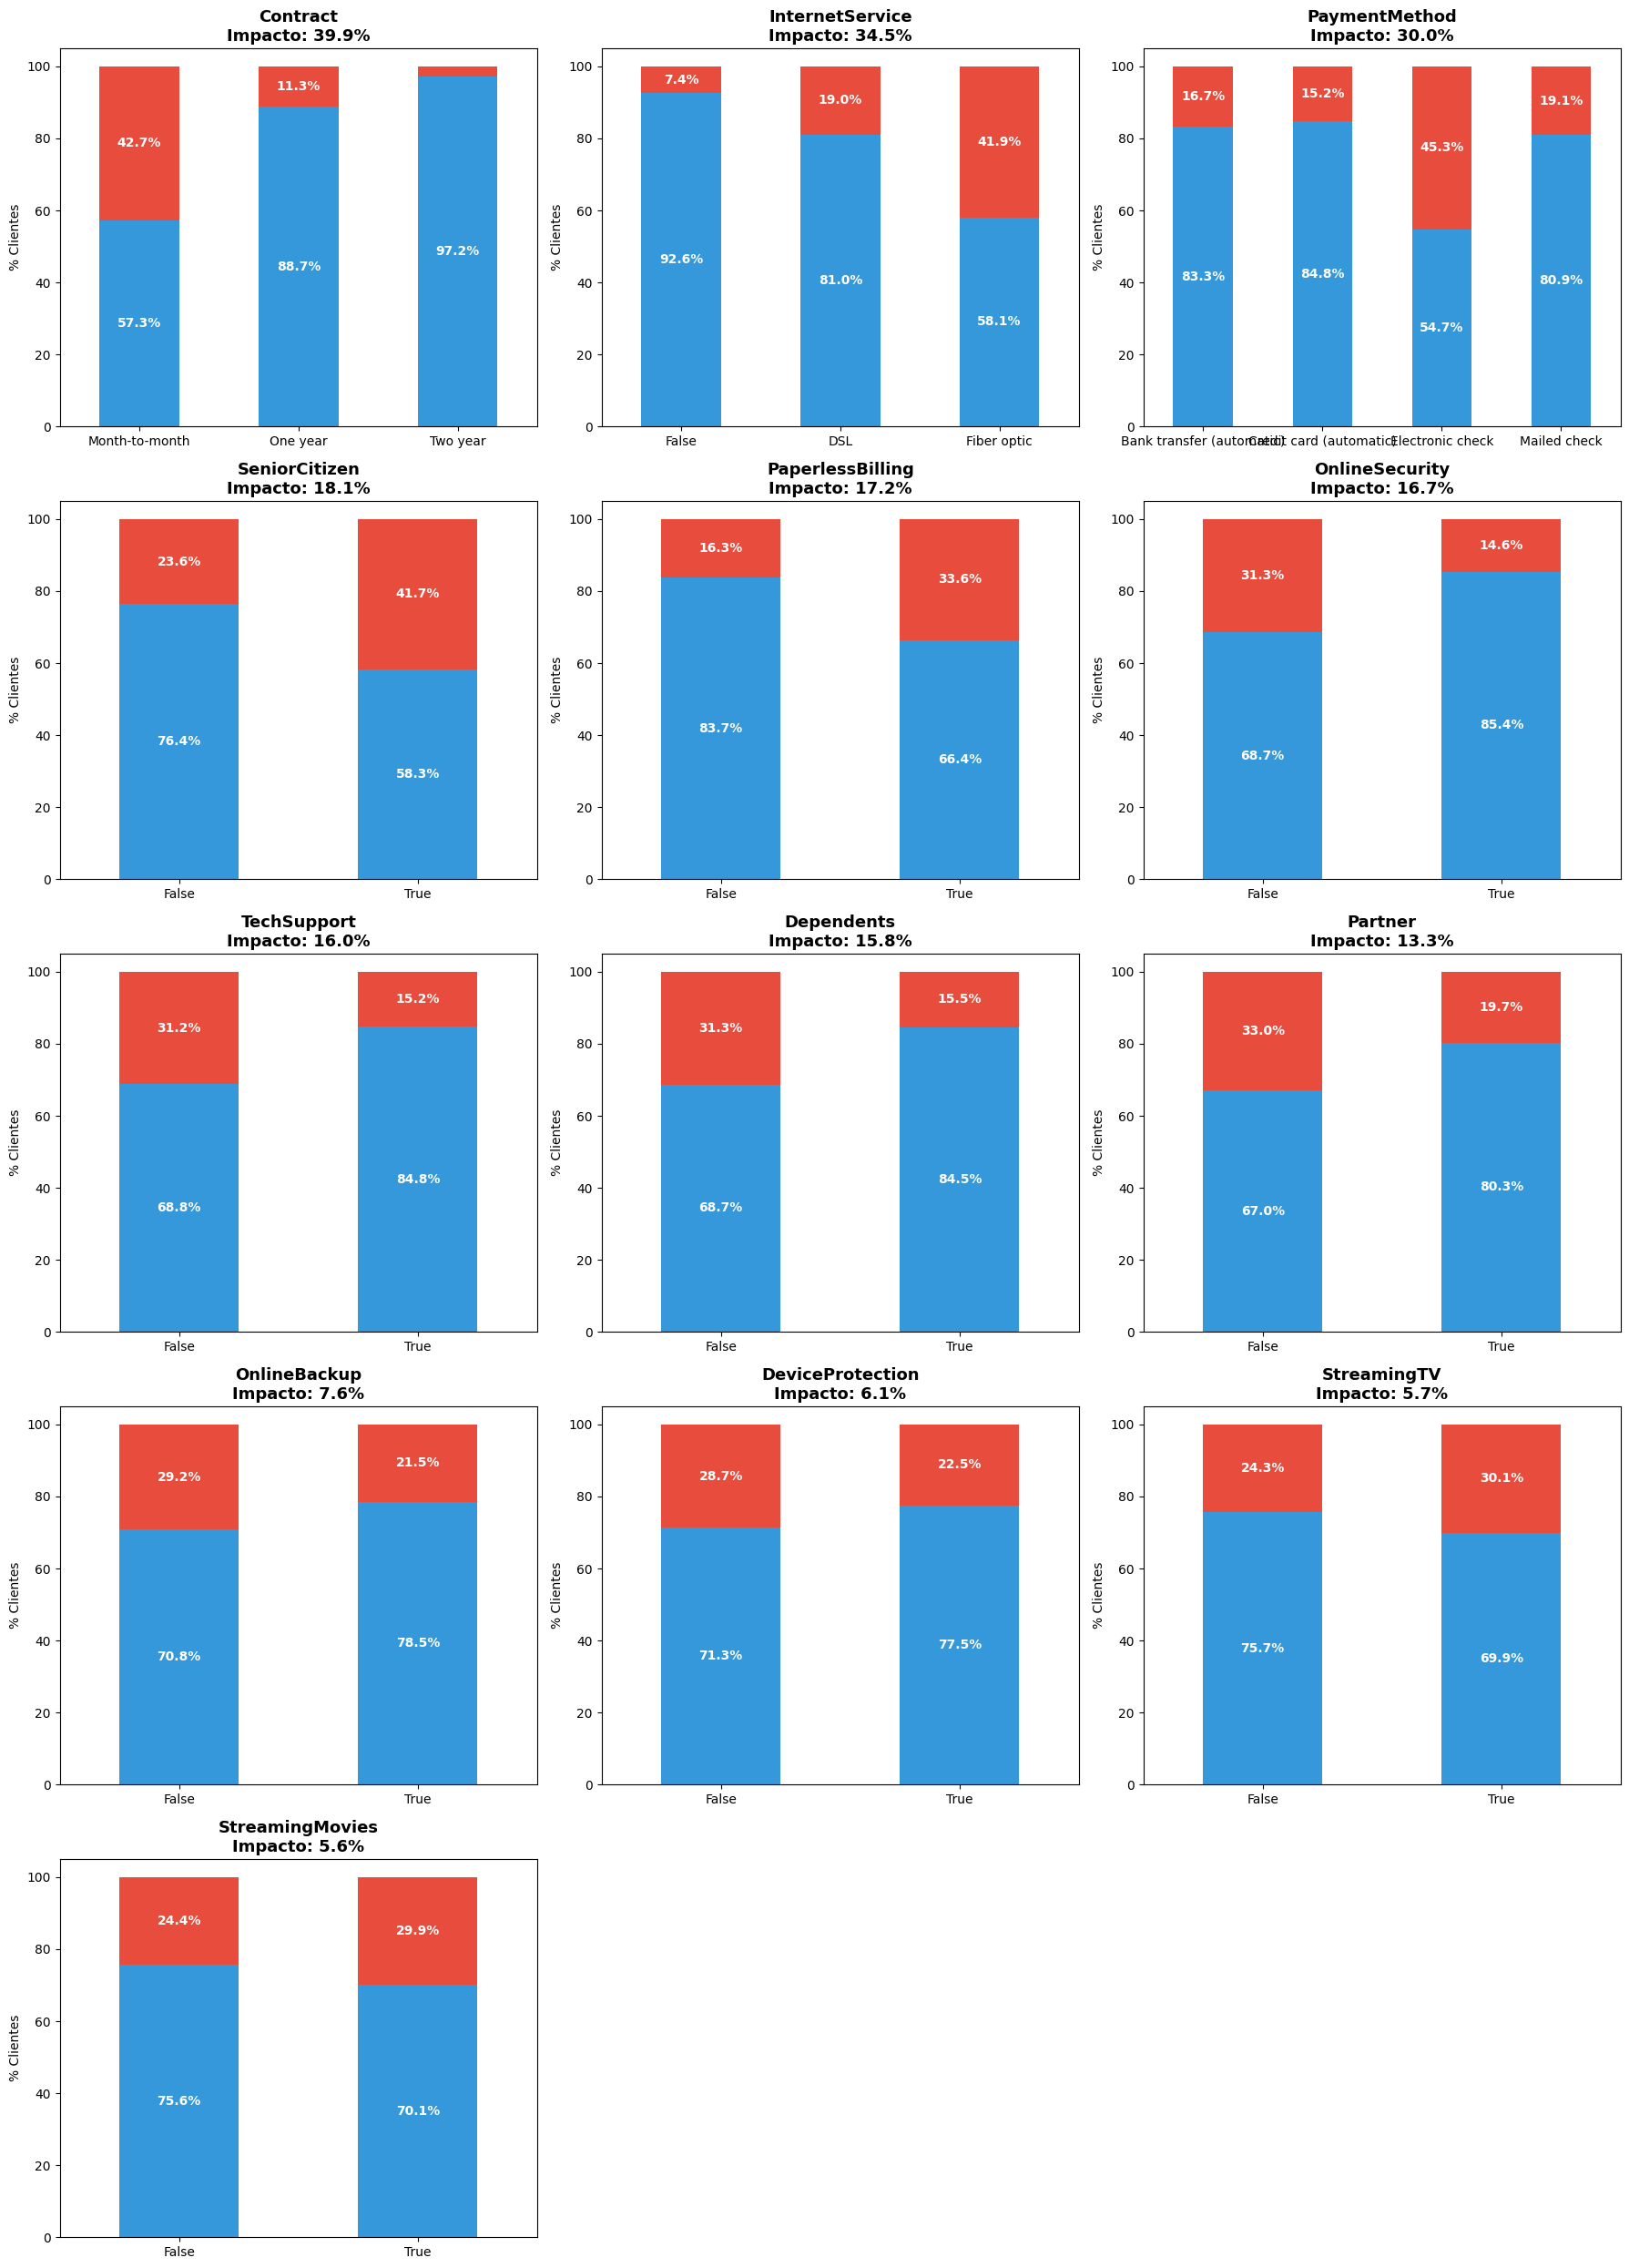

In [ ]:
# 1. Definir columnas y excluir 'tenure'
cols_to_check = [col for col in df.columns[2:19] if col not in ['tenure', 'ternure']]
impactos = []

# 2. Calcular el impacto para cada columna
for col in cols_to_check:
    # Generamos la tabla de contingencia normalizada
    ct = pd.crosstab(df[col], df['Churn'], normalize='index') * 100

    # Verificamos que existan datos de Churn (True)
    if True in ct.columns:
        # Impacto = Diferencia entre el máximo y mínimo porcentaje de Churn en las categorías
        diff = ct[True].max() - ct[True].min()
        impactos.append({'columna': col, 'impacto': diff})

# 3. Guardar y Organizar de mayor a menor
df_impactos = pd.DataFrame(impactos).sort_values(by='impacto', ascending=False)

# Filtramos solo las que tienen impacto > 5%
df_filtrado = df_impactos[df_impactos['impacto'] > 5]

print("Ranking de Impacto en Churn:")
print(df_filtrado)

# 4. Configurar la cuadrícula con las columnas ordenadas
cols_ordenadas = df_filtrado['columna'].tolist()
n_cols = 3
n_rows = math.ceil(len(cols_ordenadas) / n_cols)

if len(cols_ordenadas) > 0:
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 5))
    axes = axes.flatten()

    for i, col in enumerate(cols_ordenadas):
        # Obtener el valor del impacto para el título
        val_impacto = df_filtrado[df_filtrado['columna'] == col]['impacto'].values[0]

        reporte_pct = pd.crosstab(df[col], df['Churn'], normalize='index') * 100

        # Graficar (Ordenando también las barras para que sean consistentes)
        reporte_pct.plot(kind='bar', stacked=True, ax=axes[i], color=['#3498db', '#e74c3c'], legend=False)

        axes[i].set_title(f'{col}\nImpacto: {val_impacto:.1f}%', fontsize=13, fontweight='bold')
        axes[i].set_ylabel('% Clientes')
        axes[i].set_xlabel('')
        axes[i].tick_params(axis='x', rotation=0)

        # Añadir etiquetas
        for p in axes[i].patches:
            h = p.get_height()
            if h > 5:
                axes[i].annotate(f'{h:.1f}%', (p.get_x() + p.get_width()/2., p.get_y() + h/2.),
                                 ha='center', va='center', color='white', fontsize=10, fontweight='bold')

    # Ocultar cuadros vacíos
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("Ninguna columna superó el umbral del 5% de impacto.")

Conteo de evasion por variables numericas

In [ ]:
df.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,Cuentas_Diarias
0,0002-ORFBO,False,Female,False,True,True,9,True,False,DSL,...,False,True,True,False,One year,True,Mailed check,65.6,593.3,2.19
1,0003-MKNFE,False,Male,False,False,False,9,True,True,DSL,...,False,False,False,True,Month-to-month,False,Mailed check,59.9,542.4,2.00
2,0004-TLHLJ,True,Male,False,False,False,4,True,False,Fiber optic,...,True,False,False,False,Month-to-month,True,Electronic check,73.9,280.85,2.46
3,0011-IGKFF,True,Male,True,True,False,13,True,False,Fiber optic,...,True,False,True,True,Month-to-month,True,Electronic check,98.0,1237.85,3.27
4,0013-EXCHZ,True,Female,True,True,False,3,True,False,Fiber optic,...,False,True,True,False,Month-to-month,True,Mailed check,83.9,267.4,2.80


#📄Informe final

In [ ]:
print("Unique values in 'Charges.Total':", df['Charges.Total'].unique())
print("Number of non-numeric values in 'Charges.Total':", pd.to_numeric(df['Charges.Total'], errors='coerce').isnull().sum())

Unique values in 'Charges.Total': ['593.3' '542.4' '280.85' ... '742.9' '4627.65' '3707.6']
Number of non-numeric values in 'Charges.Total': 11


In [ ]:
df['Charges.Total'] = pd.to_numeric(df['Charges.Total'], errors='coerce')
df['Charges.Total'] = df['Charges.Total'].fillna(df['Charges.Total'].median())
df.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,Cuentas_Diarias
0,0002-ORFBO,False,Female,False,True,True,9,True,False,DSL,...,False,True,True,False,One year,True,Mailed check,65.6,593.30,2.19
1,0003-MKNFE,False,Male,False,False,False,9,True,True,DSL,...,False,False,False,True,Month-to-month,False,Mailed check,59.9,542.40,2.00
2,0004-TLHLJ,True,Male,False,False,False,4,True,False,Fiber optic,...,True,False,False,False,Month-to-month,True,Electronic check,73.9,280.85,2.46
3,0011-IGKFF,True,Male,True,True,False,13,True,False,Fiber optic,...,True,False,True,True,Month-to-month,True,Electronic check,98.0,1237.85,3.27
4,0013-EXCHZ,True,Female,True,True,False,3,True,False,Fiber optic,...,False,True,True,False,Month-to-month,True,Mailed check,83.9,267.40,2.80


## Bin 'Charges.Total' y Conversión

Crear 5 grupos (bins) para las columnas 'Charges.Total' y 'tenure'.


In [ ]:
df['Charges.Total_Bins'] = pd.qcut(df['Charges.Total'], q=5, labels=False)
df['tenure_Bins'] = pd.qcut(df['tenure'], q=5, labels=False)
df.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,Cuentas_Diarias,Charges.Total_Bins,tenure_Bins
0,0002-ORFBO,False,Female,False,True,True,9,True,False,DSL,...,True,False,One year,True,Mailed check,65.6,593.30,2.19,1,1
1,0003-MKNFE,False,Male,False,False,False,9,True,True,DSL,...,False,True,Month-to-month,False,Mailed check,59.9,542.40,2.00,1,1
2,0004-TLHLJ,True,Male,False,False,False,4,True,False,Fiber optic,...,False,False,Month-to-month,True,Electronic check,73.9,280.85,2.46,1,0
3,0011-IGKFF,True,Male,True,True,False,13,True,False,Fiber optic,...,True,True,Month-to-month,True,Electronic check,98.0,1237.85,3.27,2,1
4,0013-EXCHZ,True,Female,True,True,False,3,True,False,Fiber optic,...,True,False,Month-to-month,True,Mailed check,83.9,267.40,2.80,1,0


In [ ]:
churn_by_charges_bins = pd.crosstab(df['Charges.Total_Bins'], df['Churn'], normalize='index') * 100
churn_by_tenure_bins = pd.crosstab(df['tenure_Bins'], df['Churn'], normalize='index') * 100

print("Churn Rate by Charges.Total Bins:")
print(churn_by_charges_bins)

print("\nChurn Rate by Tenure Bins:")
print(churn_by_tenure_bins)

Churn Rate by Charges.Total Bins:
Churn                   False      True 
Charges.Total_Bins                      
0                   54.009936  45.990064
1                   71.093750  28.906250
2                   79.347055  20.652945
3                   76.988636  23.011364
4                   85.876508  14.123492

Churn Rate by Tenure Bins:
Churn            False      True 
tenure_Bins                      
0            47.062795  52.937205
1            66.571224  33.428776
2            77.627841  22.372159
3            84.444444  15.555556
4            93.390192   6.609808


## Informe Final: Análisis de la Tasa de Abandono por Cargos Totales y Antigüedad

Este informe presenta las conclusiones y recomendaciones clave derivadas del análisis de la tasa de abandono (`Churn`) en función de los `Charges.Total` (cargos totales) y `tenure` (antigüedad del cliente), ambos discretizados en 5 cuartiles (bins).

### Conclusiones Clave

#### 1. Impacto de los Cargos Totales (`Charges.Total_Bins`)

El análisis de la tasa de abandono por grupos de cargos totales revela una clara correlación inversa:

*   **Bin 0 (Cargos Totales más Bajos):** Presenta la tasa de abandono más alta, alcanzando aproximadamente el **46%**. Esto sugiere que los clientes con los gastos totales más bajos son los más propensos a abandonar el servicio.
*   **Bins Intermedios (1, 2 y 3):** Muestran una disminución progresiva en la tasa de abandono, con porcentajes de **28.9%, 20.7% y 23.0%** respectivamente. Aunque el bin 3 tiene una tasa ligeramente superior al bin 2, la tendencia general es a la baja.
*   **Bin 4 (Cargos Totales más Altos):** Registra la tasa de abandono más baja, cerca del **14.1%**. Esto indica que los clientes con un mayor gasto total son considerablemente más leales.

En resumen, a medida que los clientes invierten más en los servicios (mayores `Charges.Total`), su propensión a abandonar disminuye significativamente.

#### 2. Impacto de la Antigüedad del Cliente (`tenure_Bins`)

La antigüedad del cliente es un predictor aún más fuerte del abandono, mostrando una relación inversa muy marcada:

*   **Bin 0 (Antigüedad más Baja):** Exhibe la tasa de abandono más alarmante, superando el **52.9%**. Esto subraya que los clientes en sus primeros meses de servicio son extremadamente vulnerables al abandono.
*   **Bins Intermedios (1, 2 y 3):** La tasa de abandono cae drásticamente a medida que aumenta la antigüedad, con tasas del **33.4%, 22.4% y 15.6%** respectivamente. Esto demuestra la importancia de la retención temprana.
*   **Bin 4 (Antigüedad más Alta):** Tiene una tasa de abandono excepcionalmente baja, de solo el **6.6%**. Esto confirma que los clientes de larga duración son los más estables y leales.

En conclusión, la probabilidad de abandono disminuye drásticamente a medida que los clientes permanecen más tiempo con la compañía, siendo los nuevos clientes el grupo de mayor riesgo.

### Recomendaciones Estratégicas

Basándonos en estas conclusiones, se proponen las siguientes recomendaciones para reducir la tasa de abandono:

1.  **Foco en la Retención Temprana de Clientes (Antigüedad Baja):**
    *   **Programas de Onboarding Mejorados:** Implementar programas robustos para nuevos clientes que aseguren una integración fluida y satisfactoria. Esto podría incluir tutoriales personalizados, soporte proactivo y comunicaciones regulares durante los primeros 3-6 meses.
    *   **Ofertas de Bienvenida y Seguimiento:** Considerar ofertas especiales o descuentos para los primeros meses que incentiven la permanencia y un seguimiento personalizado para abordar cualquier problema inicial.

2.  **Estrategias para Clientes con Bajos Cargos Totales:**
    *   **Identificación de Insatisfacción:** Investigar las razones subyacentes del alto abandono en el segmento de bajos cargos totales (Bin 0). Podría ser una señal de que los servicios básicos no satisfacen sus expectativas o que hay un problema con la percepción de valor.
    *   **Paquetes de Valor Añadido:** Ofrecer paquetes de servicios que aumenten el valor percibido sin un costo inicial excesivo, o promociones para probar servicios adicionales que puedan mejorar su experiencia general.

3.  **Incentivar la Permanencia a Largo Plazo:**
    *   **Programas de Lealtad:** Desarrollar programas de recompensas para clientes de alta antigüedad y altos cargos totales para reconocer su lealtad y reducir aún más su ya baja propensión al abandono.
    *   **Comunicación Personalizada:** Mantener una comunicación constante y relevante con clientes leales, informándoles sobre nuevas funciones o mejoras de servicio que puedan ser de su interés.

4.  **Segmentación para Campañas de Retención:**
    *   Utilizar los bins de `Charges.Total` y `tenure` para segmentar a los clientes y diseñar campañas de retención altamente personalizadas. Por ejemplo, una campaña para un cliente nuevo con bajos cargos sería muy diferente a una para un cliente con antigüedad media y cargos altos.

Implementar estas estrategias ayudará a mitigar el abandono en los segmentos de mayor riesgo y a fortalecer la lealtad de los clientes más valiosos.

## Informe Final: Análisis de la Tasa de Abandono por Cargos Totales y Antigüedad

Este informe presenta las conclusiones y recomendaciones clave derivadas del análisis de la tasa de abandono (`Churn`) en función de los `Charges.Total` (cargos totales) y `tenure` (antigüedad del cliente), ambos discretizados en 5 cuartiles (bins).

### Conclusiones Clave

#### 1. Impacto de los Cargos Totales (`Charges.Total_Bins`)

El análisis de la tasa de abandono por grupos de cargos totales revela una clara correlación inversa:

*   **Bin 0 (Cargos Totales más Bajos):** Presenta la tasa de abandono más alta, alcanzando aproximadamente el **46%**. Esto sugiere que los clientes con los gastos totales más bajos son los más propensos a abandonar el servicio.
*   **Bins Intermedios (1, 2 y 3):** Muestran una disminución progresiva en la tasa de abandono, con porcentajes de **28.9%, 20.7% y 23.0%** respectivamente. Aunque el bin 3 tiene una tasa ligeramente superior al bin 2, la tendencia general es a la baja.
*   **Bin 4 (Cargos Totales más Altos):** Registra la tasa de abandono más baja, cerca del **14.1%**. Esto indica que los clientes con un mayor gasto total son considerablemente más leales.

En resumen, a medida que los clientes invierten más en los servicios (mayores `Charges.Total`), su propensión a abandonar disminuye significativamente.

#### 2. Impacto de la Antigüedad del Cliente (`tenure_Bins`)

La antigüedad del cliente es un predictor aún más fuerte del abandono, mostrando una relación inversa muy marcada:

*   **Bin 0 (Antigüedad más Baja):** Exhibe la tasa de abandono más alarmante, superando el **52.9%**. Esto subraya que los clientes en sus primeros meses de servicio son extremadamente vulnerables al abandono.
*   **Bins Intermedios (1, 2 y 3):** La tasa de abandono cae drásticamente a medida que aumenta la antigüedad, con tasas del **33.4%, 22.4% y 15.6%** respectivamente. Esto demuestra la importancia de la retención temprana.
*   **Bin 4 (Antigüedad más Alta):** Tiene una tasa de abandono excepcionalmente baja, de solo el **6.6%**. Esto confirma que los clientes de larga duración son los más estables y leales.

En conclusión, la probabilidad de abandono disminuye drásticamente a medida que los clientes permanecen más tiempo con la compañía, siendo los nuevos clientes el grupo de mayor riesgo.

### Recomendaciones Estratégicas

Basándonos en estas conclusiones, se proponen las siguientes recomendaciones para reducir la tasa de abandono:

1.  **Foco en la Retención Temprana de Clientes (Antigüedad Baja):**
    *   **Programas de Onboarding Mejorados:** Implementar programas robustos para nuevos clientes que aseguren una integración fluida y satisfactoria. Esto podría incluir tutoriales personalizados, soporte proactivo y comunicaciones regulares durante los primeros 3-6 meses.
    *   **Ofertas de Bienvenida y Seguimiento:** Considerar ofertas especiales o descuentos para los primeros meses que incentiven la permanencia y un seguimiento personalizado para abordar cualquier problema inicial.

2.  **Estrategias para Clientes con Bajos Cargos Totales:**
    *   **Identificación de Insatisfacción:** Investigar las razones subyacentes del alto abandono en el segmento de bajos cargos totales (Bin 0). Podría ser una señal de que los servicios básicos no satisfacen sus expectativas o que hay un problema con la percepción de valor.
    *   **Paquetes de Valor Añadido:** Ofrecer paquetes de servicios que aumenten el valor percibido sin un costo inicial excesivo, o promociones para probar servicios adicionales que puedan mejorar su experiencia general.

3.  **Incentivar la Permanencia a Largo Plazo:**
    *   **Programas de Lealtad:** Desarrollar programas de recompensas para clientes de alta antigüedad y altos cargos totales para reconocer su lealtad y reducir aún más su ya baja propensión al abandono.
    *   **Comunicación Personalizada:** Mantener una comunicación constante y relevante con clientes leales, informándoles sobre nuevas funciones o mejoras de servicio que puedan ser de su interés.

4.  **Segmentación para Campañas de Retención:**
    *   Utilizar los bins de `Charges.Total` y `tenure` para segmentar a los clientes y diseñar campañas de retención altamente personalizadas. Por ejemplo, una campaña para un cliente nuevo con bajos cargos sería muy diferente a una para un cliente con antigüedad media y cargos altos.

Implementar estas estrategias ayudará a mitigar el abandono en los segmentos de mayor riesgo y a fortalecer la lealtad de los clientes más valiosos.


## Análisis y Visualización de la Tasa de Abandono por Cargos Totales

### Subtask:
Visualizar la tasa de abandono por 'Charges.Total' binned.


**Reasoning**:
To visualize the churn rate by 'Charges.Total_Bins', I will create a stacked bar chart using the 'churn_by_charges_bins' DataFrame, applying the specified colors, title, and y-axis label.



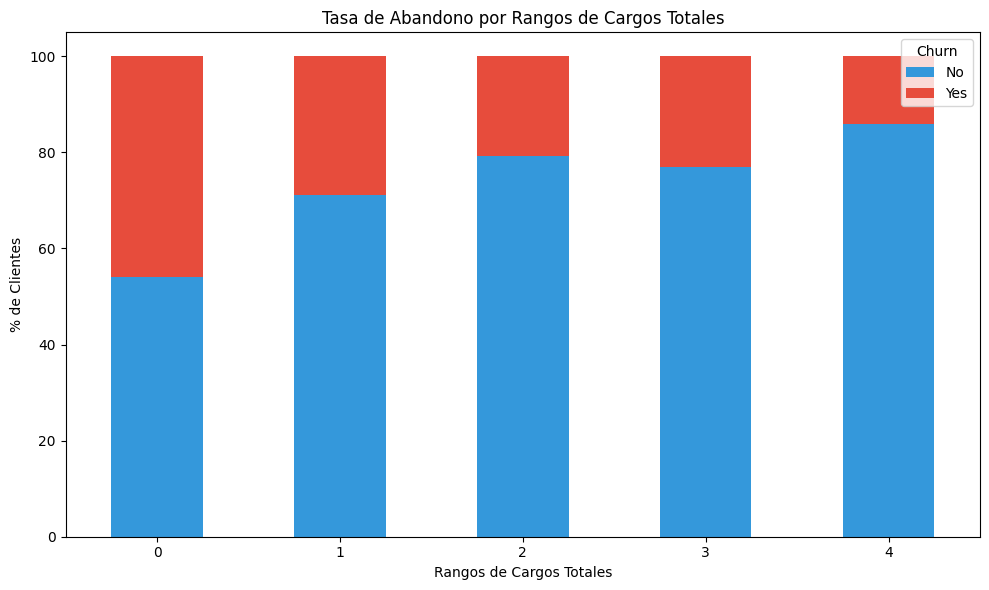

In [ ]:
churn_by_charges_bins.plot(kind='bar', stacked=True, color=['#3498db', '#e74c3c'], figsize=(10, 6))
plt.title('Tasa de Abandono por Rangos de Cargos Totales')
plt.ylabel('% de Clientes')
plt.xlabel('Rangos de Cargos Totales')
plt.xticks(rotation=0)
plt.legend(title='Churn', labels=['No', 'Yes'])
plt.tight_layout()
plt.show()

**Reasoning**:
To visualize the churn rate by 'tenure_Bins', I will create a stacked bar chart using the 'churn_by_tenure_bins' DataFrame, applying similar colors, title, and y-axis label for consistency.



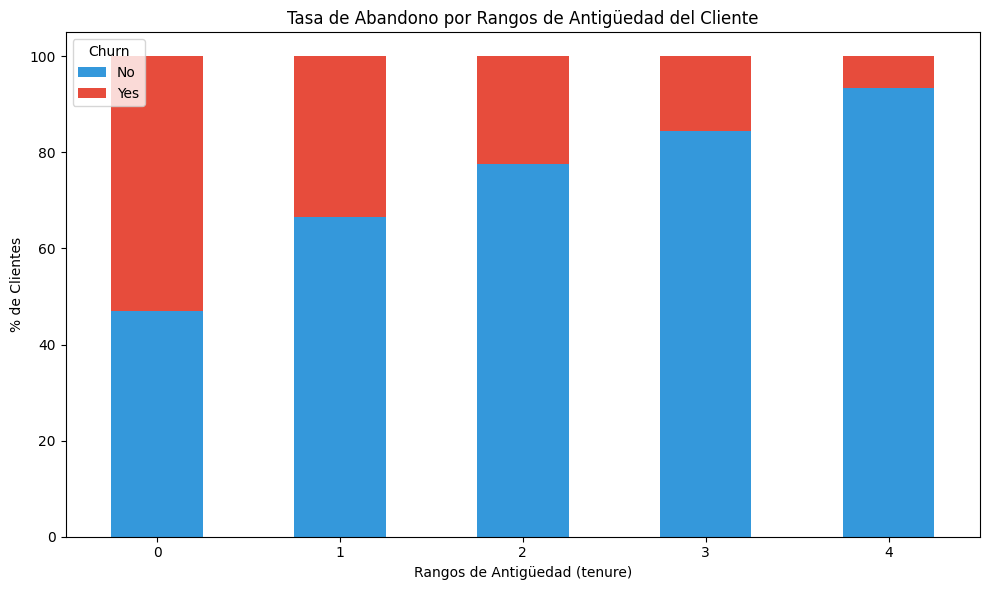

In [ ]:
churn_by_tenure_bins.plot(kind='bar', stacked=True, color=['#3498db', '#e74c3c'], figsize=(10, 6))
plt.title('Tasa de Abandono por Rangos de Antigüedad del Cliente')
plt.ylabel('% de Clientes')
plt.xlabel('Rangos de Antigüedad (tenure)')
plt.xticks(rotation=0)
plt.legend(title='Churn', labels=['No', 'Yes'])
plt.tight_layout()
plt.show()

# Informe de Análisis de Abandono de Clientes (TelecomX)

## 1. Extracción y Limpieza Inicial de Datos

- **Carga de Datos:** Se importó el archivo `TelecomX_Data.json` en un DataFrame de pandas. Inicialmente, las columnas `customer`, `phone`, `internet` y `account` estaban en formato JSON anidado.  
- **Normalización de JSON:** Se desanidaron esas columnas con `pd.json_normalize`, creando una tabla plana.  
- **Simplificación de Nombres de Columnas:** Se eliminaron los prefijos (ej. `customer.gender` → `gender`) para mayor claridad.  
- **Tratamiento de Valores Nulos:** La columna `Churn` contenía valores vacíos. Se reemplazaron por `NaN` y se eliminaron esas filas, quedando solo clientes con etiqueta “Yes” o “No”.  
- **Normalización de Valores Booleanos:** Se estandarizaron valores como `Yes/No`, `No phone service`, `No internet service` a `True/False`. La columna `SeniorCitizen` pasó de 0/1 a booleanos.  
- **Creación de `Cuentas_Diarias`:** Se añadió una columna calculando el gasto diario promedio (`Charges.Monthly / 30`), redondeado a dos decimales.  

---

## 2. Preparación para el Análisis de Abandono (Churn Rate)

- **Conversión de `Charges.Total`:** Se transformó a tipo numérico. Los valores no convertibles se reemplazaron con la mediana.  
- **Creación de Bins:** Se discretizaron `Charges.Total` y `tenure` en 5 grupos (cuartiles), generando las columnas `Charges.Total_Bins` y `tenure_Bins`.  

---

## 3. Análisis y Visualización de la Tasa de Abandono

- **Impacto de `Charges.Total_Bins`:**  
  - Bin 0 (gastos más bajos): tasa de abandono ≈ 46%.  
  - Bin 4 (gastos más altos): tasa de abandono ≈ 14.1%.  
  → A mayor gasto, menor probabilidad de abandono.  

- **Gráfico de Churn por Cargos Totales:** Barras apiladas muestran cómo la proporción de clientes que abandonan disminuye en bins de mayor gasto.  

- **Impacto de `tenure_Bins`:**  
  - Bin 0 (antigüedad más baja): tasa de abandono ≈ 52.9%.  
  - Bin 4 (antigüedad más alta): tasa de abandono ≈ 6.6%.  
  → Los clientes nuevos son los más vulnerables; los antiguos, los más leales.  

- **Gráfico de Churn por Antigüedad:** Barras apiladas evidencian la caída drástica del abandono conforme aumenta la antigüedad.  

---

## 4. Conclusiones y Recomendaciones Clave

- **Conclusiones:**  
  - Existe una correlación inversa entre cargos totales y antigüedad con la tasa de abandono.  
  - Los clientes nuevos y de bajo gasto son los segmentos de mayor riesgo.  

- **Recomendaciones Estratégicas:**  
  - **Retención temprana:** Programas de onboarding, soporte proactivo y ofertas de bienvenida.  
  - **Clientes de bajos cargos:** Investigar causas de insatisfacción y ofrecer paquetes de valor añadido.  
  - **Lealtad a largo plazo:** Programas de recompensas y comunicación personalizada para clientes de alta antigüedad y gasto.  
  - **Segmentación de campañas:** Usar los bins de gasto y antigüedad para diseñar estrategias diferenciadas según el perfil de riesgo.  


## Tabla Comparativa de Tasa de Abandono

| Segmento (Bin) | Charges.Total (Tasa de Abandono) | Tenure (Tasa de Abandono) |
|----------------|----------------------------------|---------------------------|
| Bin 0          | ~46%                             | ~52.9%                    |
| Bin 1          | ↓ (menor que Bin 0)              | ↓ (menor que Bin 0)       |
| Bin 2          | ↓                                | ↓                         |
| Bin 3          | ↓                                | ↓                         |
| Bin 4          | ~14.1%                           | ~6.6%                     |

**Notas:**
- Los porcentajes exactos solo se reportan para los extremos (Bin 0 y Bin 4), ya que son los más representativos.  
- La tendencia es clara: a mayor gasto (`Charges.Total`) y mayor antigüedad (`tenure`), menor tasa de abandono.  
- Los clientes nuevos y de bajo gasto son los más vulnerables.  
